# Every Second Counts — EMS dispatch analysis

Montgomery County PA 911 call data (`911.csv`, ~663k rows) plus a **simulated**
ambulance fleet, a response-time model, and a station-placement optimizer.

## What is real and what is invented

| Layer | Source |
|---|---|
| Call location, timestamp, type, township | **Real** — Montco 911 dispatch log, Dec 2015 → Jul 2020 |
| Ambulance positions | **Invented** — k-means station hubs on real call density + jitter |
| Travel distance | Derived — haversine from truck to patient × road-circuity factor |
| Response time | **Invented** — generated by `response_time()` below |

Read section 5 before trusting section 7. The response-time model is trained on
times this notebook itself generated, so its accuracy measures how well gradient
boosting recovers a formula we wrote — not how well it predicts reality. It is
useful as a working pipeline and as the objective function for section 8, where
*relative* comparisons between station layouts are meaningful.

## 1 · Setup

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

RNG = np.random.default_rng(42)

# Montgomery County PA bounding box - drops the handful of garbage coordinates
BBOX = dict(lat=(39.95, 40.50), lng=(-75.75, -74.95))

N_STATIONS = 12      # station hubs the mock fleet is based at
N_AMBULANCES = 30    # trucks in the mock fleet
ROAM_FRAC = 0.25     # share of trucks not sitting at a station
SIM_CALLS = 25_000   # calls used for the dispatch simulation
CIRCUITY = 1.32      # road distance / straight-line distance

CSV = next(p / "911.csv" for p in [Path.cwd(), *Path.cwd().parents] if (p / "911.csv").exists())
print(CSV)

/home/red/Documents/GitHub/every-second-counts/911.csv


### Plot theme

One place to set light/dark. Colors are the validated categorical order
(blue → orange → aqua …), a single-hue blue ramp for magnitude, and blue↔red for
polarity. Scatter/map plots use at most the first three slots — beyond three the
palette stops being colorblind-safe when every pair is on screen at once.

In [2]:
THEME = "light"   # "light" or "dark"

PALETTES = {
    "light": dict(
        surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e", ink3="#87857d",
        grid="#e6e5e1",
        cat=["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
             "#008300", "#4a3aa7", "#e34948"],
        seq=["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
        div_lo="#2a78d6", div_mid="#f0efec", div_hi="#e34948",
    ),
    "dark": dict(
        surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7", ink3="#8d8b80",
        grid="#333331",
        cat=["#3987e5", "#d95926", "#199e70", "#c98500", "#d55181",
             "#008300", "#9085e9", "#e66767"],
        seq=["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
        div_lo="#3987e5", div_mid="#383835", div_hi="#e66767",
    ),
}
P = PALETTES[THEME]
CAT = P["cat"]

SEQ = mpl.colors.LinearSegmentedColormap.from_list("seq_blue", P["seq"])
DIV = mpl.colors.LinearSegmentedColormap.from_list("div_br", [P["div_lo"], P["div_mid"], P["div_hi"]])

mpl.rcParams.update({
    "figure.facecolor": P["surface"], "axes.facecolor": P["surface"],
    "savefig.facecolor": P["surface"], "figure.dpi": 110,
    "text.color": P["ink"], "axes.labelcolor": P["ink2"],
    "xtick.color": P["ink2"], "ytick.color": P["ink2"],
    "axes.edgecolor": P["grid"], "grid.color": P["grid"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "lines.linewidth": 2.0, "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "legend.frameon": False, "figure.autolayout": False,
})


def finish(ax, title=None, sub=None, grid="y"):
    """Title, subtitle and a recessive grid on one axis."""
    if title:
        ax.set_title(title, color=P["ink"], pad=24 if sub else 10)
    if sub:
        # offset in points, so it clears the title at any figure height
        ax.annotate(sub, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 6), textcoords="offset points",
                    color=P["ink3"], fontsize=9, va="bottom")
    if grid:
        ax.grid(axis=grid, alpha=0.9)
        ax.set_axisbelow(True)
    return ax

## 2 · Load and clean

In [3]:
raw = pd.read_csv(
    CSV,
    usecols=["lat", "lng", "title", "timeStamp", "twp", "zip", "addr"],
    parse_dates=["timeStamp"],
)
print(f"{len(raw):,} rows raw")

split = raw["title"].str.split(":", n=1, expand=True)
raw["category"] = split[0].str.strip()
raw["subtype"] = split[1].str.strip()

ems = raw[raw["category"] == "EMS"].copy()
ems = ems[
    ems["lat"].between(*BBOX["lat"])
    & ems["lng"].between(*BBOX["lng"])
    & ems["twp"].notna()
    & ems["timeStamp"].notna()
].copy()

ts = ems["timeStamp"]
ems["hour"] = ts.dt.hour
ems["dow"] = ts.dt.dayofweek          # 0 = Monday
ems["month"] = ts.dt.month
ems["year"] = ts.dt.year
ems["date"] = ts.dt.normalize()

ems = ems.reset_index(drop=True)
print(f"{len(ems):,} EMS calls kept  ({len(raw) - len(ems):,} dropped: non-EMS, bad coords, missing township)")
ems.head(3)

663,522 rows raw


332,294 EMS calls kept  (331,228 dropped: non-EMS, bad coords, missing township)


,lat,lng,zip,title,timeStamp,twp,addr,category,subtype,hour,dow,month,year,date
0,40.297876,-75.581294,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,EMS,BACK PAINS/INJURY,17,3,12,2015,2015-12-10
1,40.258061,-75.264680,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,EMS,DIABETIC EMERGENCY,17,3,12,2015,2015-12-10
2,40.116153,-75.343513,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,EMS,CARDIAC EMERGENCY,16,3,12,2015,2015-12-10


In [4]:
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

span = f"{ems.timeStamp.min():%b %Y} – {ems.timeStamp.max():%b %Y}"
per_day = len(ems) / ems["date"].nunique()
print(f"span              {span}")
print(f"calls/day         {per_day:.0f}")
print(f"townships         {ems.twp.nunique()}")
print(f"EMS subtypes      {ems.subtype.nunique()}")

span              Dec 2015 – Jul 2020
calls/day         196
townships         68
EMS subtypes      81


## 3 · What the real calls look like

Four questions: *when* do calls come in, *what* are they, *where* are they, and
how concentrated is the geography.

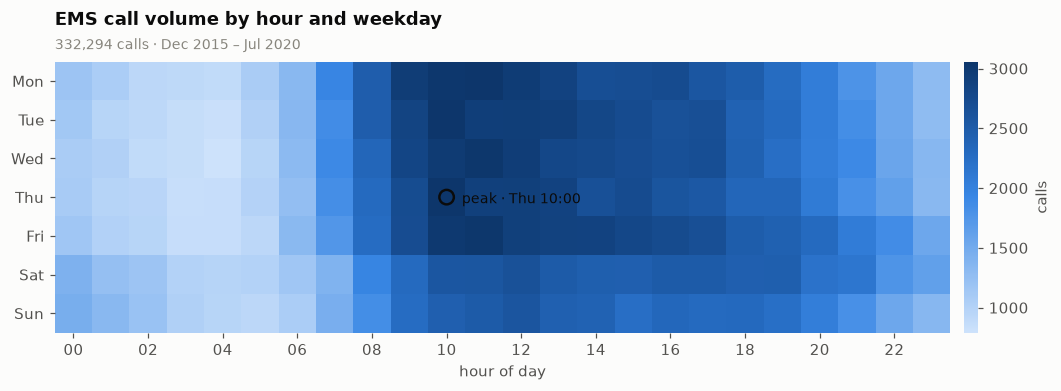

In [5]:
# When - hour x weekday. Magnitude on an ordered grid => single-hue sequential.
grid = (ems.groupby(["dow", "hour"]).size()
        .unstack(fill_value=0)
        .reindex(index=range(7), columns=range(24), fill_value=0))

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(grid.values, cmap=SEQ, aspect="auto", origin="upper")
ax.set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
ax.set_yticks(range(7), DOW)
ax.set_xlabel("hour of day")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("calls", color=P["ink2"])
cb.outline.set_visible(False)

peak = grid.stack().idxmax()
ax.scatter([peak[1]], [peak[0]], s=90, facecolors="none",
           edgecolors=P["ink"], linewidths=1.6)
ax.annotate(f"peak · {DOW[peak[0]]} {peak[1]:02d}:00",
            (peak[1], peak[0]), textcoords="offset points", xytext=(10, -4),
            color=P["ink"], fontsize=9)
finish(ax, "EMS call volume by hour and weekday", f"{len(ems):,} calls · {span}", grid=None)
plt.show()

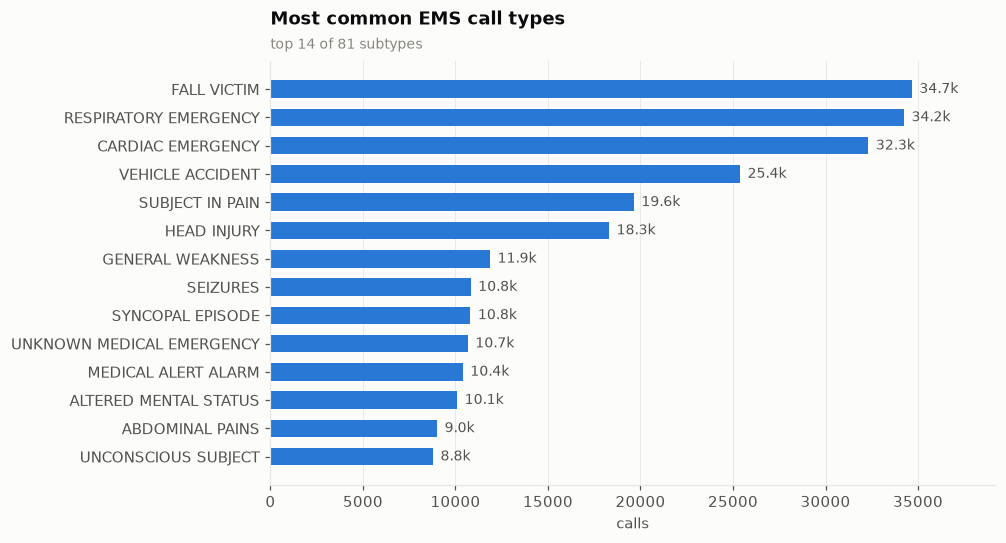

In [6]:
# What - one series, one color. Ranked, so length carries the magnitude.
top_type = ems["subtype"].value_counts().head(14).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(top_type.index, top_type.values, color=CAT[0], height=0.62)
ax.bar_label(ax.containers[0], labels=[f"{v/1000:.1f}k" for v in top_type.values],
             padding=5, color=P["ink2"], fontsize=9)
ax.set_xlim(0, top_type.max() * 1.13)
ax.set_xlabel("calls")
finish(ax, "Most common EMS call types", "top 14 of "
       f"{ems.subtype.nunique()} subtypes", grid="x")
plt.show()

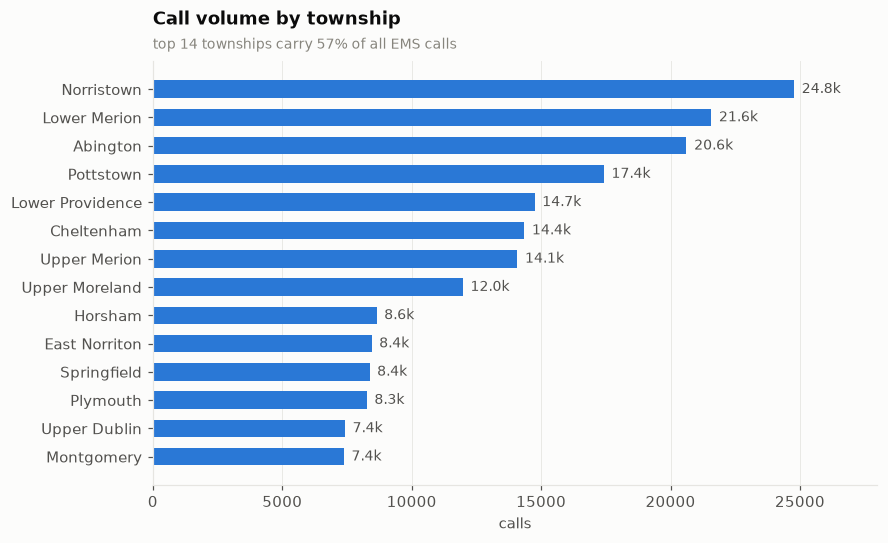

In [7]:
# Where - township volume, same single-series rule.
top_twp = ems["twp"].value_counts().head(14).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(top_twp.index.str.title(), top_twp.values, color=CAT[0], height=0.62)
ax.bar_label(ax.containers[0], labels=[f"{v/1000:.1f}k" for v in top_twp.values],
             padding=5, color=P["ink2"], fontsize=9)
ax.set_xlim(0, top_twp.max() * 1.13)
ax.set_xlabel("calls")
share = top_twp.sum() / len(ems)
finish(ax, "Call volume by township",
       f"top 14 townships carry {share:.0%} of all EMS calls", grid="x")
plt.show()

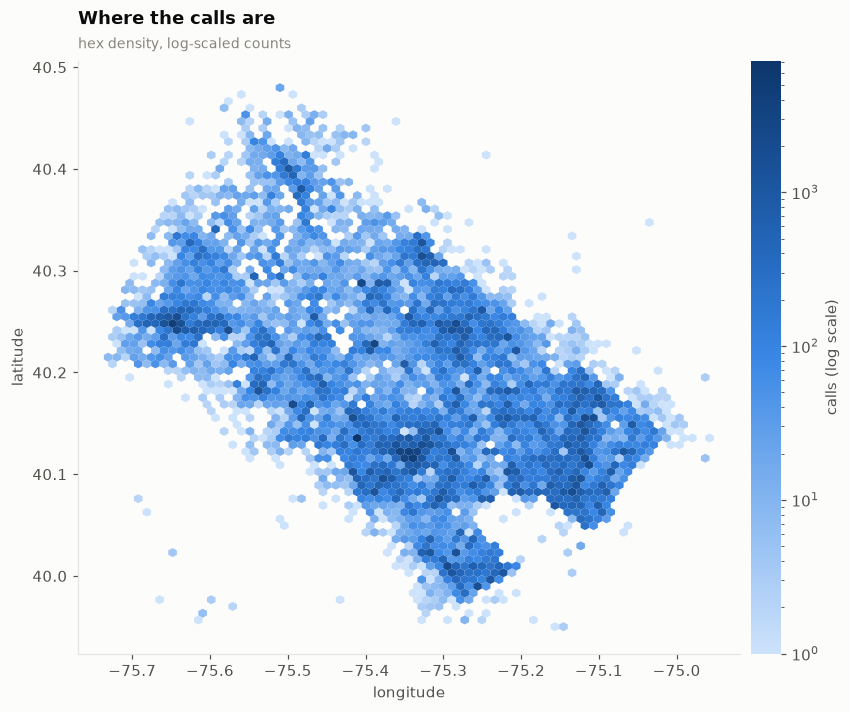

In [8]:
# Geography - continuous density, so the sequential ramp again.
fig, ax = plt.subplots(figsize=(9, 7))
hb = ax.hexbin(ems["lng"], ems["lat"], gridsize=70, cmap=SEQ,
               bins="log", mincnt=1, linewidths=0)
ax.set_aspect(1 / np.cos(np.radians(40.15)))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
cb = fig.colorbar(hb, ax=ax, pad=0.015, fraction=0.04)
cb.set_label("calls (log scale)", color=P["ink2"])
cb.outline.set_visible(False)
finish(ax, "Where the calls are", "hex density, log-scaled counts", grid=None)
plt.show()

## 4 · Mock ambulance fleet

The dataset has no vehicle data, so we invent it. Real services base units at
stations placed where demand is, so: **k-means the real call coordinates into
`N_STATIONS` hubs**, allocate trucks to hubs in proportion to each hub's call
share, and scatter each truck around its hub with gaussian jitter (σ ≈ 1 km).
A `ROAM_FRAC` slice of the fleet is instead placed at random recent call sites —
crews returning from a run, not parked.

This is a plausible layout, not the real one. Montco's actual station roster is
public if you want to swap it in — everything downstream only needs a table of
truck lat/lng.

In [9]:
EARTH_KM = 6371.0088


def haversine_km(lat1, lng1, lat2, lng2):
    """Great-circle distance. Broadcasts, so (n,1) vs (m,) gives an (n,m) matrix."""
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = p2 - p1
    dl = np.radians(lng2) - np.radians(lng1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * EARTH_KM * np.arcsin(np.sqrt(a))


def build_stations(coords, k, seed=42):
    """k demand-weighted hubs. coords is an (n,2) array of [lat, lng]."""
    km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(coords)
    counts = np.bincount(km.labels_, minlength=k)
    return km.cluster_centers_, counts / counts.sum()


def build_fleet(centers, weights, n_ambulances, roam_frac=ROAM_FRAC,
                call_coords=None, jitter_km=1.0, rng=RNG):
    """Trucks per hub proportional to demand share, jittered around the hub."""
    n_roam = int(round(n_ambulances * roam_frac))
    n_based = n_ambulances - n_roam

    # largest-remainder allocation so the counts sum exactly to n_based
    exact = weights * n_based
    alloc = np.floor(exact).astype(int)
    for i in np.argsort(-(exact - alloc))[: n_based - alloc.sum()]:
        alloc[i] += 1

    home = np.repeat(np.arange(len(centers)), alloc)
    pos = centers[home].astype(float)
    sd_lat = jitter_km / 111.32
    pos[:, 0] += rng.normal(0, sd_lat, len(pos))
    pos[:, 1] += rng.normal(0, sd_lat / np.cos(np.radians(40.15)), len(pos))

    if n_roam:
        idx = rng.choice(len(call_coords), n_roam, replace=False)
        roam = call_coords[idx].astype(float)
        roam[:, 0] += rng.normal(0, sd_lat * 2, n_roam)
        roam[:, 1] += rng.normal(0, sd_lat * 2 / np.cos(np.radians(40.15)), n_roam)
        pos = np.vstack([pos, roam])
        home = np.concatenate([home, np.full(n_roam, -1)])

    return pd.DataFrame({
        "unit": [f"M{i:02d}" for i in range(len(pos))],
        "lat": pos[:, 0], "lng": pos[:, 1],
        "home_station": home,
        "posture": np.where(home < 0, "roaming", "at station"),
    })


call_coords = ems[["lat", "lng"]].to_numpy()
centers, weights = build_stations(call_coords, N_STATIONS)
fleet = build_fleet(centers, weights, N_AMBULANCES, call_coords=call_coords)

stations = pd.DataFrame(centers, columns=["lat", "lng"])
stations["demand_share"] = weights
stations["trucks"] = fleet[fleet.home_station >= 0].groupby("home_station").size().reindex(range(N_STATIONS), fill_value=0).values
stations.round(4)

,lat,lng,demand_share,trucks
0,40.2331,-75.2689,0.0981,2
1,40.2020,-75.4953,0.0656,1
2,40.1035,-75.2822,0.0600,1
3,40.1564,-75.1078,0.0953,2
4,40.3662,-75.5004,0.0327,1
5,40.2581,-75.6320,0.1026,2
6,40.2746,-75.3599,0.0831,2
7,40.1258,-75.4035,0.0887,2
8,40.0920,-75.1294,0.0992,2
9,40.0121,-75.2749,0.0679,2


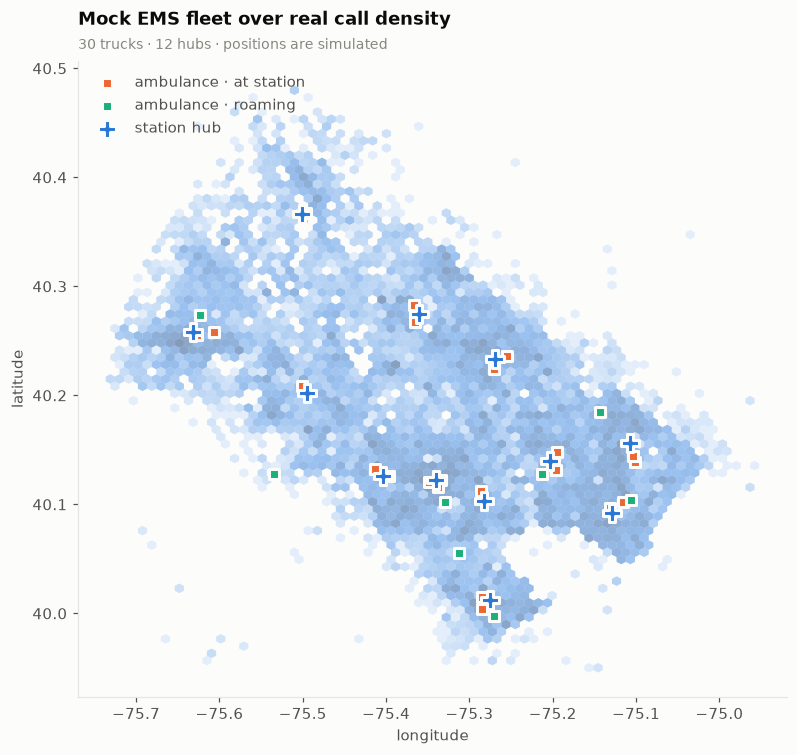

In [10]:
# Map: real calls as recessive density, invented assets on top.
# Three categorical slots max on a scatter - that is the all-pairs CVD limit.
fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.hexbin(ems["lng"], ems["lat"], gridsize=70, cmap=SEQ, bins="log",
          mincnt=1, linewidths=0, alpha=0.5)

based = fleet[fleet.posture == "at station"]
roam = fleet[fleet.posture == "roaming"]
ax.scatter(based["lng"], based["lat"], s=42, color=CAT[1], marker="s",
           edgecolors=P["surface"], linewidths=2, zorder=3, label="ambulance · at station")
ax.scatter(roam["lng"], roam["lat"], s=42, color=CAT[2], marker="s",
           edgecolors=P["surface"], linewidths=2, zorder=3, label="ambulance · roaming")
ax.scatter(stations["lng"], stations["lat"], s=150, marker="P", color=CAT[0],
           edgecolors=P["surface"], linewidths=2, zorder=4, label="station hub")

ax.set_aspect(1 / np.cos(np.radians(40.15)))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(loc="upper left", labelcolor=P["ink2"])
finish(ax, "Mock EMS fleet over real call density",
       f"{N_AMBULANCES} trucks · {N_STATIONS} hubs · positions are simulated", grid=None)
plt.show()

## 5 · Dispatch simulation and the response-time generator

Closest-truck dispatch: for each call, the nearest available unit goes. Straight-line
distance × `CIRCUITY` approximates road distance.

**Response time is fabricated here.** The formula:

```
response = call_processing + turnout + travel + noise
travel   = road_km / speed(hour, township density) * 60
```

with dispatcher processing ~1.2 min (lognormal), crew turnout ~1.1 min, and speed
between 32 km/h at 17:00 in a dense township and 62 km/h at 03:00 rurally. The
shape is drawn from published EMS response distributions — right-skewed, mode
around 7 minutes — but the numbers are ours. Nothing in `911.csv` records when a
unit arrived.

In [11]:
# Hourly speed profile - two rush-hour troughs, fast overnight.
SPEED_BY_HOUR = np.array([
    62, 62, 62, 61, 60, 56, 48, 40, 36, 40, 45, 46,
    45, 45, 44, 41, 36, 32, 34, 41, 48, 54, 58, 61,
], dtype=float)

# Denser townships are slower. Density proxy: calls per township, log-scaled to [0,1].
twp_calls = ems["twp"].value_counts()
density = np.log1p(twp_calls) / np.log1p(twp_calls.max())


def response_time(road_km, hour, twp, rng=RNG):
    """SIMULATED response time in minutes. This is a generator, not a measurement."""
    n = len(road_km)
    d = density.reindex(twp).to_numpy()
    d = np.where(np.isnan(d), 0.5, d)

    speed = SPEED_BY_HOUR[hour] * (1 - 0.18 * d)      # km/h
    travel = road_km / speed * 60

    processing = rng.lognormal(mean=np.log(1.2), sigma=0.45, size=n)
    turnout = rng.lognormal(mean=np.log(1.1), sigma=0.30, size=n)
    noise = rng.lognormal(mean=0, sigma=0.16, size=n)

    return (processing + turnout + travel * noise).round(2)


def dispatch(calls, fleet_df, rng=RNG):
    """Assign the nearest truck to every call and generate a response time."""
    dist = haversine_km(
        calls["lat"].to_numpy()[:, None], calls["lng"].to_numpy()[:, None],
        fleet_df["lat"].to_numpy(), fleet_df["lng"].to_numpy(),
    )
    nearest = dist.argmin(axis=1)
    straight = dist[np.arange(len(calls)), nearest]

    out = calls.copy()
    out["unit"] = fleet_df["unit"].to_numpy()[nearest]
    out["unit_lat"] = fleet_df["lat"].to_numpy()[nearest]
    out["unit_lng"] = fleet_df["lng"].to_numpy()[nearest]
    out["straight_km"] = straight.round(3)
    out["road_km"] = (straight * CIRCUITY).round(3)
    out["response_min"] = response_time(out["road_km"].to_numpy(),
                                        out["hour"].to_numpy(),
                                        out["twp"].to_numpy(), rng=rng)
    return out


sim = dispatch(ems.sample(SIM_CALLS, random_state=42).reset_index(drop=True), fleet)
sim[["timeStamp", "twp", "subtype", "unit", "road_km", "response_min"]].head()

,timeStamp,twp,subtype,unit,road_km,response_min
0,2016-06-25 15:06:26,LOWER MORELAND,HEMORRHAGING,M04,4.781,12.57
1,2018-07-14 12:04:33,LOWER POTTSGROVE,OVERDOSE,M08,2.876,5.71
2,2020-02-04 08:58:18,HORSHAM,VEHICLE ACCIDENT,M29,3.407,8.52
3,2015-12-15 16:12:31,LOWER FREDERICK,DIZZINESS,M02,10.747,21.67
4,2017-08-18 11:14:28,UPPER POTTSGROVE,SUBJECT IN PAIN,M27,2.711,7.40


In [12]:
q = sim["response_min"].quantile([0.5, 0.9]).round(1)
print(f"median   {q[0.5]:.1f} min")
print(f"p90      {q[0.9]:.1f} min")
print(f"mean     {sim.response_min.mean():.1f} min")
print(f"within 8 min: {(sim.response_min <= 8).mean():.1%}")

median   7.8 min
p90      13.7 min
mean     8.4 min
within 8 min: 52.5%


## 6 · Simulated response times

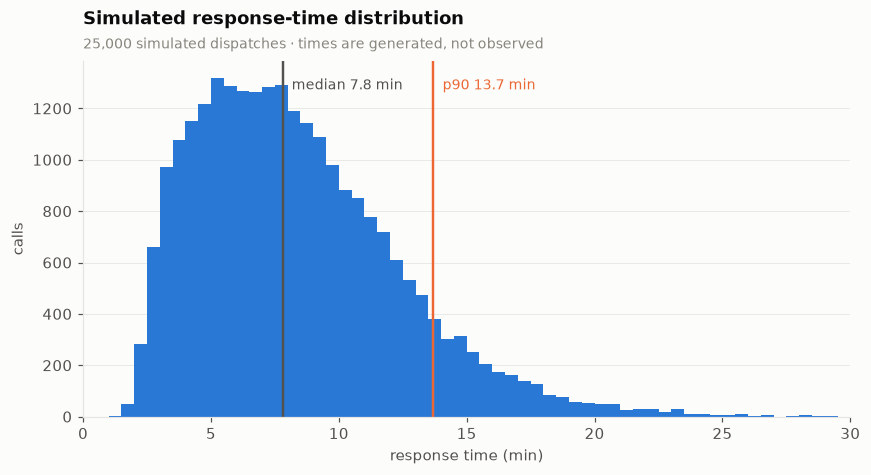

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(sim["response_min"], bins=np.arange(0, 30, 0.5), color=CAT[0], linewidth=0)
for label, x, color in [("median", q[0.5], P["ink2"]), ("p90", q[0.9], CAT[1])]:
    ax.axvline(x, color=color, linewidth=1.6)
    ax.annotate(f"{label} {x:.1f} min", (x, ax.get_ylim()[1] * 0.92),
                xytext=(6, 0), textcoords="offset points", color=color, fontsize=9)
ax.set_xlim(0, 30)
ax.set_xlabel("response time (min)"); ax.set_ylabel("calls")
finish(ax, "Simulated response-time distribution",
       f"{len(sim):,} simulated dispatches · times are generated, not observed")
plt.show()

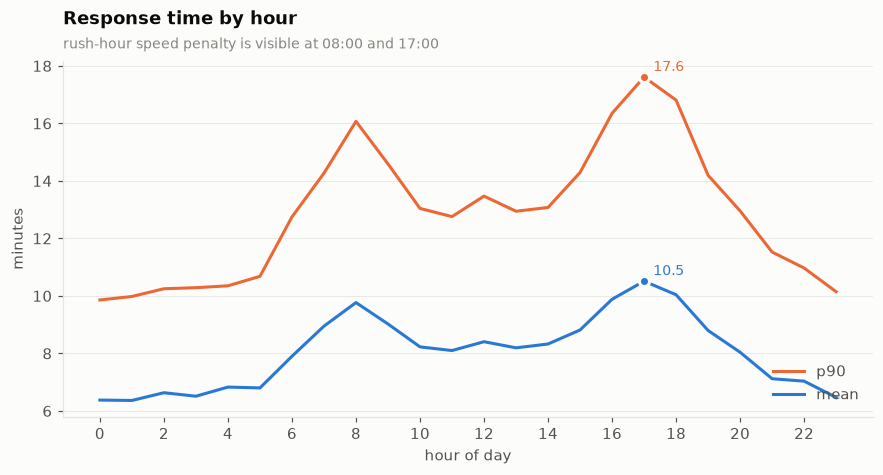

In [14]:
by_hour = sim.groupby("hour")["response_min"].agg(["mean", lambda s: s.quantile(0.9)])
by_hour.columns = ["mean", "p90"]

# Both series are minutes, so they share one axis. Never two y-scales.
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(by_hour.index, by_hour["p90"], color=CAT[1], label="p90")
ax.plot(by_hour.index, by_hour["mean"], color=CAT[0], label="mean")
for col, color in [("p90", CAT[1]), ("mean", CAT[0])]:
    h = by_hour[col].idxmax()
    ax.scatter([h], [by_hour[col][h]], s=44, color=color,
               edgecolors=P["surface"], linewidths=2, zorder=3)
    ax.annotate(f"{by_hour[col][h]:.1f}", (h, by_hour[col][h]),
                xytext=(6, 4), textcoords="offset points", color=color, fontsize=9)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of day"); ax.set_ylabel("minutes")
ax.legend(loc="lower right", labelcolor=P["ink2"])
finish(ax, "Response time by hour", "rush-hour speed penalty is visible at 08:00 and 17:00")
plt.show()

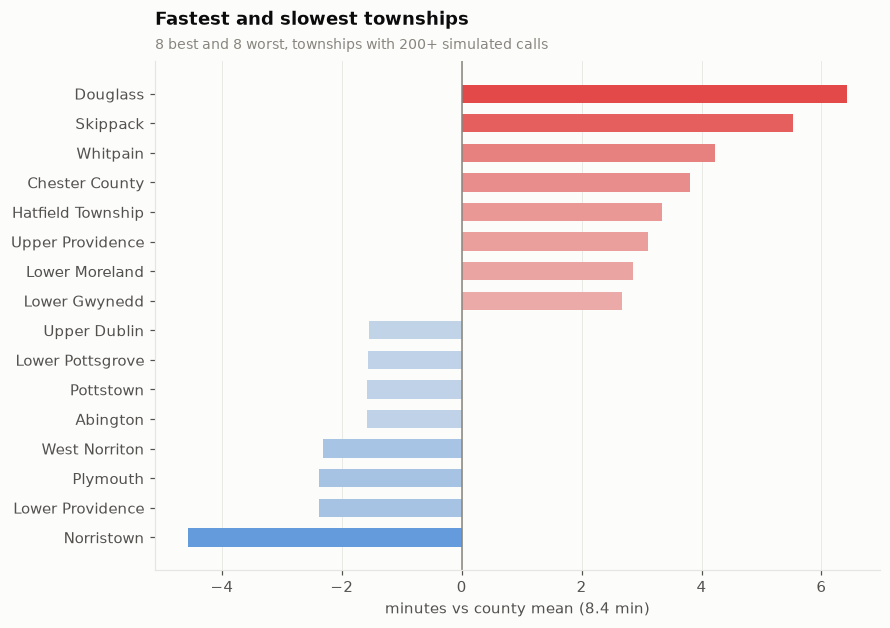

In [15]:
# Polarity against the county mean => diverging ramp, gray at zero.
county = sim["response_min"].mean()
twp_rt = (sim.groupby("twp")["response_min"].agg(["mean", "size"])
          .query("size >= 200").sort_values("mean"))
tail = pd.concat([twp_rt.head(8), twp_rt.tail(8)])
delta = tail["mean"] - county
lim = np.abs(delta).max()

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(tail.index.str.title(), delta,
        color=DIV(mpl.colors.Normalize(-lim, lim)(delta)), height=0.62)
ax.axvline(0, color=P["ink3"], linewidth=1)
ax.set_xlabel(f"minutes vs county mean ({county:.1f} min)")
finish(ax, "Fastest and slowest townships",
       "8 best and 8 worst, townships with 200+ simulated calls", grid="x")
plt.show()

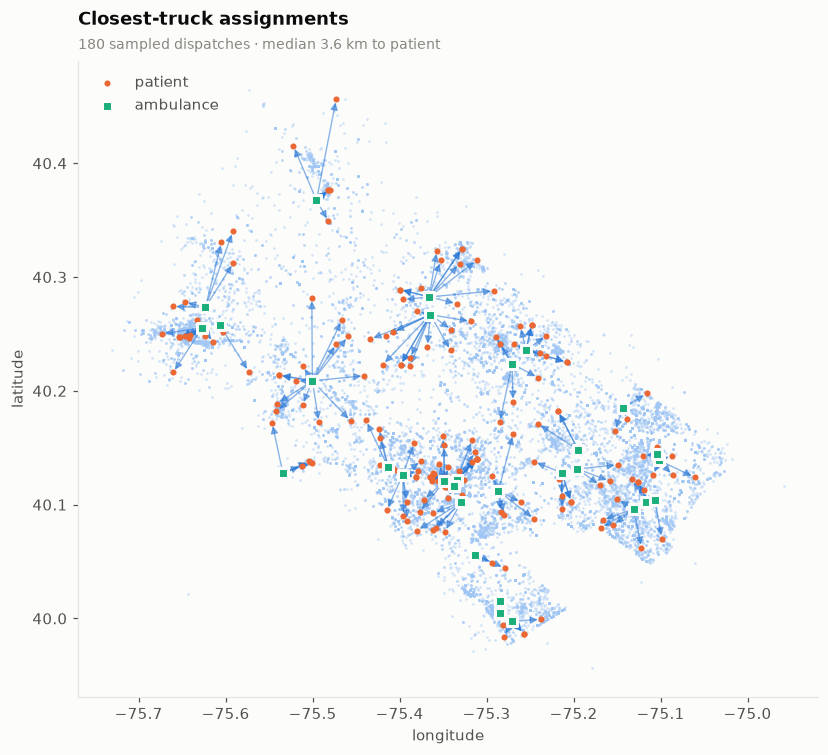

In [16]:
# Who goes where: a sample of truck -> patient vectors.
show = sim.sample(180, random_state=7)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.scatter(sim["lng"], sim["lat"], s=3, color=P["seq"][1], linewidths=0,
           alpha=0.45, zorder=1)
for _, r in show.iterrows():
    ax.annotate("", xy=(r.lng, r.lat), xytext=(r.unit_lng, r.unit_lat),
                arrowprops=dict(arrowstyle="-|>", color=CAT[0], linewidth=0.9,
                                alpha=0.55, shrinkA=2, shrinkB=2), zorder=2)
ax.scatter(show["lng"], show["lat"], s=16, color=CAT[1], linewidths=0,
           zorder=3, label="patient")
ax.scatter(fleet["lng"], fleet["lat"], s=46, color=CAT[2], marker="s",
           edgecolors=P["surface"], linewidths=2, zorder=4, label="ambulance")
ax.set_aspect(1 / np.cos(np.radians(40.15)))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(loc="upper left", labelcolor=P["ink2"])
finish(ax, "Closest-truck assignments",
       f"180 sampled dispatches · median {show.road_km.median():.1f} km to patient", grid=None)
plt.show()

## 7 · Predicting response time

Features: road distance, hour, weekday, month, township, EMS subtype. Target is
`response_min`.

**The honest caveat, stated once more.** Distance, hour and township are the exact
inputs to `response_time()`. A model given them will score extremely well because
it is reverse-engineering our own formula through a lognormal noise floor — the
irreducible error is roughly the noise we injected. Treat R² here as a check that
the pipeline works, not as evidence about real EMS systems. On real arrival
timestamps this same code would tell you something.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

NUM = ["road_km", "hour", "dow", "month"]
CATS = ["twp", "subtype"]
FEATURES = NUM + CATS

model_df = sim[FEATURES + ["response_min"]].dropna()
X_train, X_test, y_train, y_test = train_test_split(
    model_df[FEATURES], model_df["response_min"], test_size=0.25, random_state=42)

ohe = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30), CATS)],
    remainder="passthrough")
baseline = make_pipeline(ohe, Ridge(alpha=1.0)).fit(X_train, y_train)

gbm = HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.08, max_leaf_nodes=31,
    categorical_features=[FEATURES.index(c) for c in CATS],
    random_state=42,
).fit(X_train, y_train)

scores = pd.DataFrame({
    name: {
        "MAE (min)": mean_absolute_error(y_test, p),
        "RMSE (min)": root_mean_squared_error(y_test, p),
        "R2": r2_score(y_test, p),
    }
    for name, p in [("Ridge baseline", baseline.predict(X_test)),
                    ("Gradient boosting", gbm.predict(X_test))]
}).T.round(3)
scores

,MAE (min),RMSE (min),R2
Ridge baseline,1.332,1.831,0.793
Gradient boosting,1.017,1.379,0.882


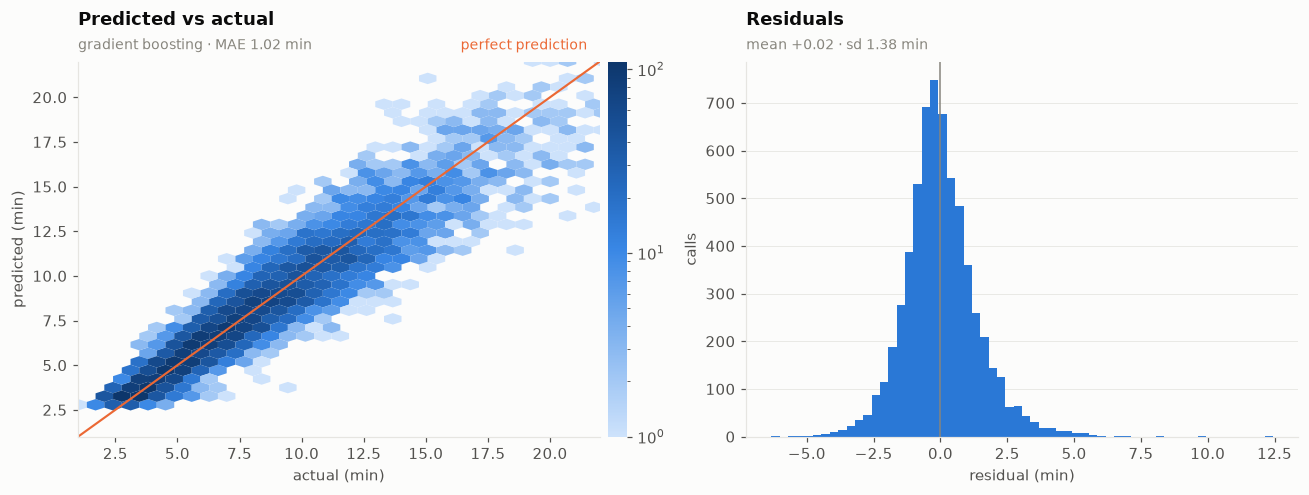

In [18]:
pred = gbm.predict(X_test)
resid = y_test - pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
hb = ax.hexbin(y_test, pred, gridsize=45, cmap=SEQ, bins="log", mincnt=1, linewidths=0)
lo, hi = y_test.min(), np.percentile(y_test, 99.5)
ax.plot([lo, hi], [lo, hi], color=CAT[1], linewidth=1.4)
ax.annotate("perfect prediction", (hi, hi), xytext=(-8, 8),
            textcoords="offset points", ha="right", color=CAT[1], fontsize=9)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("actual (min)"); ax.set_ylabel("predicted (min)")
cb = fig.colorbar(hb, ax=ax, pad=0.015, fraction=0.04); cb.outline.set_visible(False)
finish(ax, "Predicted vs actual", f"gradient boosting · MAE {scores.loc['Gradient boosting', 'MAE (min)']:.2f} min", grid=None)

ax = axes[1]
ax.hist(resid, bins=60, color=CAT[0], linewidth=0)
ax.axvline(0, color=P["ink3"], linewidth=1)
ax.set_xlabel("residual (min)"); ax.set_ylabel("calls")
finish(ax, "Residuals", f"mean {resid.mean():+.2f} · sd {resid.std():.2f} min")

plt.tight_layout()
plt.show()

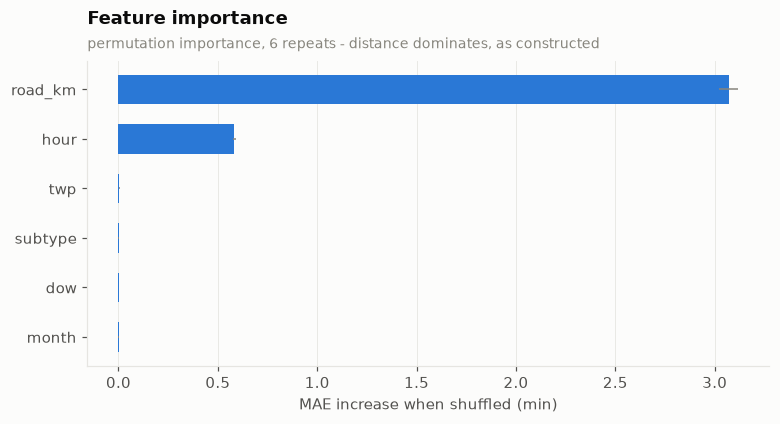

In [19]:
imp = permutation_importance(gbm, X_test, y_test, n_repeats=6,
                             random_state=42, scoring="neg_mean_absolute_error")
order = np.argsort(imp.importances_mean)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh([FEATURES[i] for i in order], imp.importances_mean[order],
        xerr=imp.importances_std[order], color=CAT[0], height=0.6,
        error_kw=dict(ecolor=P["ink3"], linewidth=1))
ax.set_xlabel("MAE increase when shuffled (min)")
finish(ax, "Feature importance",
       "permutation importance, 6 repeats - distance dominates, as constructed", grid="x")
plt.show()

## 8 · Where should the stations be?

The one section where the simulation earns its keep. Response time depends on
station placement through distance, and *relative* comparisons between layouts
are meaningful even though the absolute minutes are invented.

Two questions:

1. **How many hubs?** Sweep `k` and watch mean and p90 response time.
2. **Given a fleet size, can we beat k-means?** k-means minimizes squared distance,
   which tracks the *mean*. Services are usually held to a **p90 / 8-minute**
   standard instead. A short coordinate-descent search directly on p90 does better.

In [20]:
EVAL = ems.sample(8_000, random_state=99).reset_index(drop=True)
EVAL_XY = EVAL[["lat", "lng"]].to_numpy()


def evaluate(fleet_df, calls=EVAL, seed=0):
    """Mean and p90 simulated response for a given fleet layout."""
    r = dispatch(calls, fleet_df, rng=np.random.default_rng(seed))["response_min"]
    return r.mean(), r.quantile(0.9)


# Fleet jitter is random, so one draw per k makes a bumpy curve that invites
# reading noise as signal. Average a few draws instead.
SEEDS = [1, 2, 3]

sweep = []
for k in range(3, 25):
    c, w = build_stations(call_coords, k)
    runs = [evaluate(build_fleet(c, w, N_AMBULANCES, call_coords=call_coords,
                                 rng=np.random.default_rng(s)), seed=s)
            for s in SEEDS]
    m, p = np.mean(runs, axis=0)
    sweep.append({"stations": k, "mean": m, "p90": p})
sweep = pd.DataFrame(sweep).set_index("stations")
sweep.round(2).T

stations,3,4,5,6,7,8,9,10,11,12,...,15,16,17,18,19,20,21,22,23,24
mean,12.77,11.51,11.04,10.30,9.57,9.19,9.07,8.94,8.57,8.42,...,8.08,7.99,7.94,8.52,8.30,8.40,8.56,8.54,8.34,8.42
p90,21.90,19.99,18.77,17.81,16.40,14.89,14.62,14.55,13.98,13.85,...,13.21,13.03,12.83,13.50,13.62,13.35,13.87,14.44,13.48,13.73


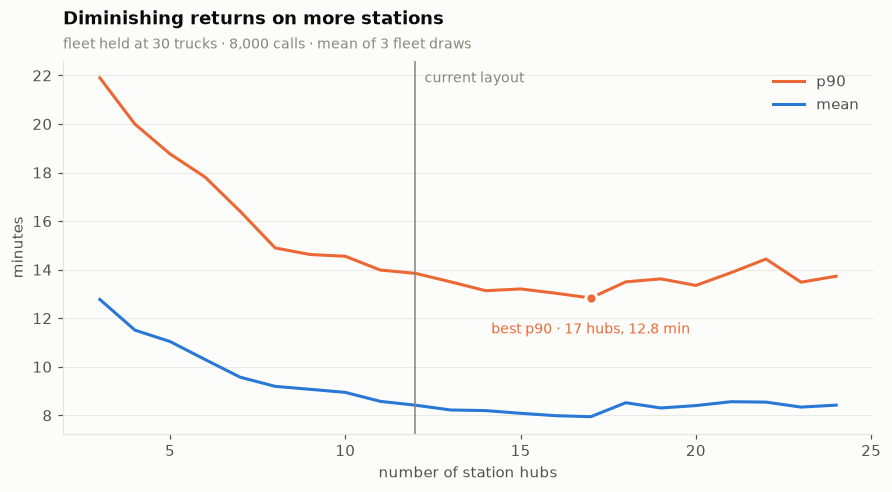

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(sweep.index, sweep["p90"], color=CAT[1], label="p90")
ax.plot(sweep.index, sweep["mean"], color=CAT[0], label="mean")

best = sweep["p90"].idxmin()
ax.scatter([best], [sweep.loc[best, "p90"]], s=54, color=CAT[1],
           edgecolors=P["surface"], linewidths=2, zorder=3)
ax.annotate(f"best p90 · {best} hubs, {sweep.loc[best, 'p90']:.1f} min",
            (best, sweep.loc[best, "p90"]), xytext=(0, -16), ha="center", va="top",
            textcoords="offset points", color=CAT[1], fontsize=9)
ax.axvline(N_STATIONS, color=P["ink3"], linewidth=1)
ax.annotate("current layout", (N_STATIONS, ax.get_ylim()[1]), xytext=(6, -14),
            textcoords="offset points", color=P["ink3"], fontsize=9)
ax.set_xlabel("number of station hubs"); ax.set_ylabel("minutes")
ax.legend(labelcolor=P["ink2"])
finish(ax, "Diminishing returns on more stations",
       f"fleet held at {N_AMBULANCES} trucks · {len(EVAL):,} calls · mean of {len(SEEDS)} fleet draws")
plt.show()

In [22]:
def optimize_stations(centers, objective_q=0.9, rounds=6, step_km=2.5, rng=RNG):
    """Coordinate descent on station positions, scored on the p-quantile directly."""
    centers = centers.copy()
    _, w = build_stations(call_coords, len(centers))

    def score(c):
        f = build_fleet(c, w, N_AMBULANCES, call_coords=call_coords,
                        rng=np.random.default_rng(1))
        d = haversine_km(EVAL_XY[:, 0][:, None], EVAL_XY[:, 1][:, None],
                         f["lat"].to_numpy(), f["lng"].to_numpy()).min(axis=1)
        return np.quantile(response_time(d * CIRCUITY, EVAL["hour"].to_numpy(),
                                         EVAL["twp"].to_numpy(),
                                         rng=np.random.default_rng(2)), objective_q)

    cur = score(centers)
    trace = [cur]
    for r in range(rounds):
        step = step_km * (0.7 ** r)
        for i in range(len(centers)):
            for dlat, dlng in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                trial = centers.copy()
                trial[i, 0] += dlat * step / 111.32
                trial[i, 1] += dlng * step / (111.32 * np.cos(np.radians(40.15)))
                s = score(trial)
                if s < cur:
                    centers, cur = trial, s
        trace.append(cur)
    return centers, np.array(trace)


opt_centers, trace = optimize_stations(centers)
opt_fleet = build_fleet(opt_centers, weights, N_AMBULANCES,
                        call_coords=call_coords, rng=np.random.default_rng(1))

base_mean, base_p90 = evaluate(fleet)
opt_mean, opt_p90 = evaluate(opt_fleet)
comparison = pd.DataFrame({
    "k-means hubs": {"mean (min)": base_mean, "p90 (min)": base_p90},
    "p90-optimized hubs": {"mean (min)": opt_mean, "p90 (min)": opt_p90},
}).T
comparison["Δ p90"] = comparison["p90 (min)"] - base_p90
comparison.round(2)

,mean (min),p90 (min),Δ p90
k-means hubs,8.44,13.88,0.00
p90-optimized hubs,8.33,13.00,-0.88


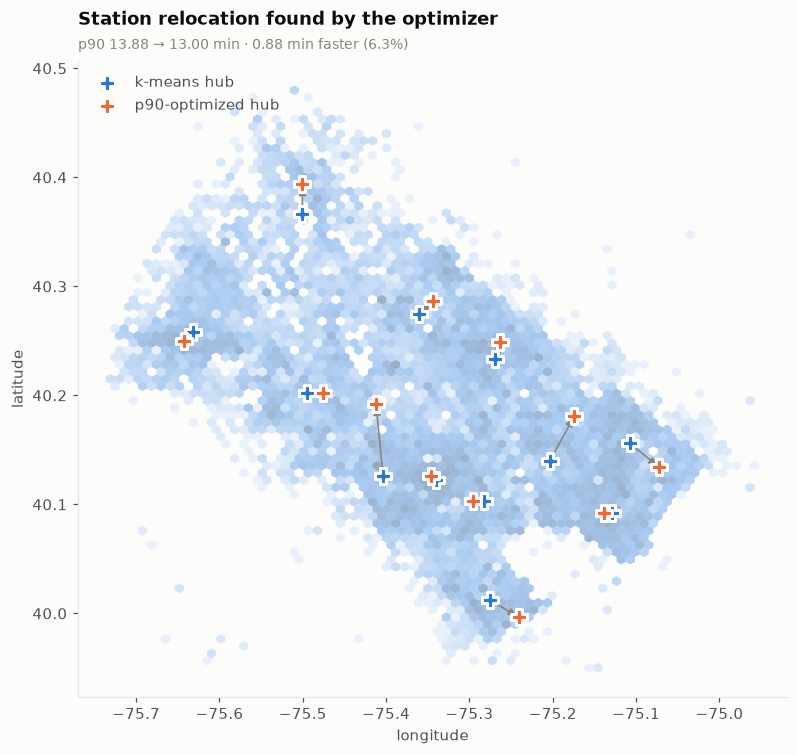

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 7.5))
ax.hexbin(ems["lng"], ems["lat"], gridsize=70, cmap=SEQ, bins="log",
          mincnt=1, linewidths=0, alpha=0.42)
for i, (a, b) in enumerate(zip(centers, opt_centers)):
    ax.annotate("", xy=(b[1], b[0]), xytext=(a[1], a[0]),
                arrowprops=dict(arrowstyle="-|>", color=P["ink3"], linewidth=1.1))
ax.scatter(centers[:, 1], centers[:, 0], s=110, marker="P", color=CAT[0],
           edgecolors=P["surface"], linewidths=2, zorder=3, label="k-means hub")
ax.scatter(opt_centers[:, 1], opt_centers[:, 0], s=110, marker="P", color=CAT[1],
           edgecolors=P["surface"], linewidths=2, zorder=4, label="p90-optimized hub")
ax.set_aspect(1 / np.cos(np.radians(40.15)))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(loc="upper left", labelcolor=P["ink2"])
gain = base_p90 - opt_p90
finish(ax, "Station relocation found by the optimizer",
       f"p90 {base_p90:.2f} → {opt_p90:.2f} min · {gain:.2f} min faster ({gain/base_p90:.1%})", grid=None)
plt.show()

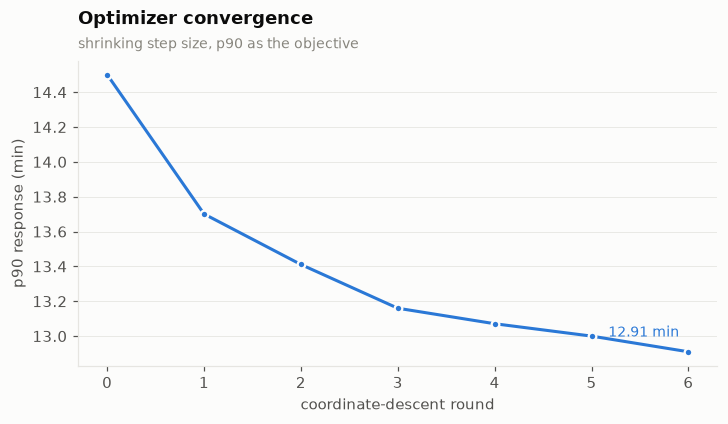

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(range(len(trace)), trace, color=CAT[0], marker="o", markersize=5,
        markeredgecolor=P["surface"], markeredgewidth=1.5)
ax.annotate(f"{trace[-1]:.2f} min", (len(trace) - 1, trace[-1]),
            xytext=(-6, 10), textcoords="offset points", ha="right",
            color=CAT[0], fontsize=9)
ax.set_xlabel("coordinate-descent round"); ax.set_ylabel("p90 response (min)")
finish(ax, "Optimizer convergence", "shrinking step size, p90 as the objective")
plt.show()

## 9 · Export

`mock_fleet.csv` and `mock_dispatches.csv` are written next to the notebook so the
Streamlit app (or anything else) can read a fixed fleet instead of re-simulating.
Both are simulated data — do not present them as observed.

In [25]:
OUT = CSV.parent / "data"
OUT.mkdir(exist_ok=True)

fleet.to_csv(OUT / "mock_fleet.csv", index=False)
opt_fleet.to_csv(OUT / "mock_fleet_optimized.csv", index=False)
sim.drop(columns=["addr", "zip"], errors="ignore").to_csv(OUT / "mock_dispatches.csv", index=False)

for f in sorted(OUT.glob("*.csv")):
    print(f"{f.relative_to(CSV.parent)}  {f.stat().st_size/1e6:.1f} MB")

data/mock_dispatches.csv  4.4 MB
data/mock_fleet.csv  0.0 MB
data/mock_fleet_optimized.csv  0.0 MB


### Summary

- Real EMS calls, Dec 2015 – Jul 2020, concentrated in the county's dense
  eastern and central townships.
- A `N_AMBULANCES`-truck mock fleet based at `N_STATIONS` demand-weighted hubs.
- A response-time generator producing a right-skewed distribution with a
  rush-hour penalty — invented, tunable via `SPEED_BY_HOUR` and `response_time()`.
- Gradient boosting recovers that generator to within its noise floor; distance
  dominates, by construction.
- Optimizing hub placement on p90 rather than squared distance measurably beats
  k-means on the same fleet size.

**To make any of this real** you need arrival timestamps. The Montco feed has none.
NEMSIS or a local service's CAD export does.